# Malicious URL Detector — Training Pipeline

End-to-end pipeline: load datasets → harmonize labels → extract features → train Random Forest → external validation → save model → generate presentation charts.

**Final model**: `models/rf_model.pkl` — bundled with label convention and feature columns, gzip-compressed.


## 1. Setup

In [1]:
import os
import re
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


## 2. Load PhiUSIIL dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("ndarvind/phiusiil-phishing-url-dataset")
df_phi = pd.read_csv(f"{path}/PhiUSIIL_Phishing_URL_Dataset.csv")

print("PhiUSIIL shape:", df_phi.shape)
print(df_phi["label"].value_counts())


Using Colab cache for faster access to the 'phiusiil-phishing-url-dataset' dataset.
PhiUSIIL shape: (235795, 55)
label
1    134850
0    100945
Name: count, dtype: int64


## 3. Load real-world dataset

In [3]:
df_rw = pd.read_csv("url_data_mega_deep_learning.csv")
print("Real-world shape:", df_rw.shape)
print(df_rw["isMalicious"].value_counts())


Real-world shape: (194798, 2)
isMalicious
0    97399
1    97399
Name: count, dtype: int64


## 4. Harmonize labels

PhiUSIIL uses `label=1` for **legitimate** and `label=0` for **phishing** — opposite of the real-world dataset. Flip PhiUSIIL so `1 = malicious` in both. This is the convention the deployed app expects.


In [4]:
df_phi["label"] = 1 - df_phi["label"]
print("PhiUSIIL after flip (1 = malicious):")
print(df_phi["label"].value_counts())


PhiUSIIL after flip (1 = malicious):
label
0    134850
1    100945
Name: count, dtype: int64


## 5. Engineered URL features (11)

`fe_is_https` was removed after an ablation study showed it acted partly as a dataset fingerprint (every PhiUSIIL URL is https, no real-world URL is).

**This extractor must match `feature_extractor.py` in the app folder.**


In [5]:
SUSPICIOUS_TOKENS = ["login", "verify", "secure", "account", "update", "confirm", "bank"]

FEATURE_COLUMNS = [
    "fe_url_length",
    "fe_num_special_chars",
    "fe_has_suspicious_token",
    "fe_digit_ratio",
    "fe_entropy",
    "fe_num_subdomains",
    "fe_is_ip",
    "fe_domain_length",
    "fe_hyphen_count",
    "fe_at_symbol",
    "fe_path_depth",
]


def extract_url_features(url):
    url = str(url)
    parsed = urlparse(url)
    hostname = parsed.hostname or ""
    path = parsed.path or ""

    length = len(url)
    num_special = sum(url.count(c) for c in ["@", "!", "$", "%", "#"])
    has_suspicious = int(any(t in url.lower() for t in SUSPICIOUS_TOKENS))
    digit_ratio = sum(c.isdigit() for c in url) / (length + 1)

    if length > 0:
        char_freq = {c: url.count(c) / length for c in set(url)}
        entropy = -sum(f * np.log2(f) for f in char_freq.values() if f > 0)
    else:
        entropy = 0.0

    return {
        "fe_url_length": length,
        "fe_num_special_chars": num_special,
        "fe_has_suspicious_token": has_suspicious,
        "fe_digit_ratio": digit_ratio,
        "fe_entropy": entropy,
        "fe_num_subdomains": hostname.count("."),
        "fe_is_ip": int(bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", hostname))),
        "fe_domain_length": len(hostname),
        "fe_hyphen_count": hostname.count("-"),
        "fe_at_symbol": int("@" in url),
        "fe_path_depth": path.count("/"),
    }


## 6. Extract features from both datasets

In [6]:
print("Extracting features from PhiUSIIL URLs...")
X_phi = df_phi["URL"].apply(extract_url_features).apply(pd.Series)[FEATURE_COLUMNS]
y_phi = df_phi["label"].astype(int)

print("Extracting features from real-world URLs...")
X_rw = df_rw["url"].apply(extract_url_features).apply(pd.Series)[FEATURE_COLUMNS]
y_rw = df_rw["isMalicious"].astype(int)

print(f"PhiUSIIL: {X_phi.shape}, Real-world: {X_rw.shape}")


Extracting features from PhiUSIIL URLs...
Extracting features from real-world URLs...
PhiUSIIL: (235795, 11), Real-world: (194798, 11)


## 7. In-domain baseline — LR on PhiUSIIL only

In [7]:
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(
    X_phi, y_phi, test_size=0.2, random_state=42, stratify=y_phi
)

lr_phi = LogisticRegression(max_iter=1000)
lr_phi.fit(Xp_tr, yp_tr)
acc_phi_only = accuracy_score(yp_te, lr_phi.predict(Xp_te))
print(f"PhiUSIIL-only LR accuracy: {acc_phi_only:.4f}")


PhiUSIIL-only LR accuracy: 0.8484


## 8. Cross-dataset generalization

Train on PhiUSIIL, evaluate on the real-world dataset. Measures how well features transfer across URL distributions.


In [8]:
acc_cross = accuracy_score(y_rw, lr_phi.predict(X_rw))
print(f"PhiUSIIL-trained LR on real-world data: {acc_cross:.4f}\n")
print(classification_report(y_rw, lr_phi.predict(X_rw), digits=3))


PhiUSIIL-trained LR on real-world data: 0.4913

              precision    recall  f1-score   support

           0      0.337     0.018     0.034     97399
           1      0.496     0.964     0.655     97399

    accuracy                          0.491    194798
   macro avg      0.416     0.491     0.344    194798
weighted avg      0.416     0.491     0.344    194798



## 9. LR on combined dataset

In [9]:
X_all = pd.concat([X_phi, X_rw], ignore_index=True)
y_all = pd.concat([y_phi, y_rw], ignore_index=True)

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

lr_both = LogisticRegression(max_iter=1000)
lr_both.fit(Xa_tr, ya_tr)
acc_lr_both = accuracy_score(ya_te, lr_both.predict(Xa_te))
print(f"Combined LR accuracy: {acc_lr_both:.4f}")


Combined LR accuracy: 0.6567


## 10. Random Forest — final model

In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(Xa_tr, ya_tr)

rf_pred = rf.predict(Xa_te)
acc_rf_both = accuracy_score(ya_te, rf_pred)

print(f"Combined RF accuracy: {acc_rf_both:.4f}\n")
print(classification_report(ya_te, rf_pred, digits=3))

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)


Combined RF accuracy: 0.8953

              precision    recall  f1-score   support

           0      0.903     0.902     0.903     46450
           1      0.886     0.887     0.886     39669

    accuracy                          0.895     86119
   macro avg      0.895     0.895     0.895     86119
weighted avg      0.895     0.895     0.895     86119


Feature importances:
fe_url_length              0.193299
fe_entropy                 0.188807
fe_domain_length           0.188664
fe_path_depth              0.182532
fe_digit_ratio             0.116732
fe_num_subdomains          0.067778
fe_has_suspicious_token    0.037955
fe_hyphen_count            0.012919
fe_num_special_chars       0.006228
fe_at_symbol               0.005074
fe_is_ip                   0.000012
dtype: float64


## 11. External validation — ealvaradob/phishing-dataset

Third-party URL dataset the model has never seen. A true out-of-distribution test. Same label convention (`1 = phishing`).


In [11]:
# Download the HuggingFace dataset repo (JSON files) via snapshot_download.
# This avoids the deprecated `trust_remote_code` loader script path.
!pip -q install huggingface_hub

from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id="ealvaradob/phishing-dataset",
    repo_type="dataset",
    local_dir="hf_phishing_dataset",
)
print("Downloaded to:", local_dir)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Downloaded to: /content/hf_phishing_dataset


In [12]:
# Load the URL subset.
JSON_PATH = "hf_phishing_dataset/urls.json"
try:
    df_ext = pd.read_json(JSON_PATH)
except ValueError:
    df_ext = pd.read_json(JSON_PATH, lines=True)

print("Shape:", df_ext.shape)
print("Columns:", df_ext.columns.tolist())
print(df_ext["label"].value_counts())
df_ext.head(3)


Shape: (835697, 2)
Columns: ['text', 'label']
label
0    444933
1    390764
Name: count, dtype: int64


,text,label
0,http://webmail-brinkster.com/ex/?email=%20%0%,1
1,billsportsmaps.com/?p=1206,0
2,www.sanelyurdu.com/language/homebank.tsbbank.c...,1


In [13]:
# Overlap check — ealvaradob was compiled from public sources, may overlap with our training data.
train_urls = set(df_rw["url"]).union(set(df_phi["URL"]))
overlap_mask = df_ext["text"].isin(train_urls)
overlap_count = int(overlap_mask.sum())
pct = overlap_count / len(df_ext) * 100

print(f"External dataset : {len(df_ext):>8,} URLs")
print(f"Training URL set : {len(train_urls):>8,} URLs")
print(f"Overlapping URLs : {overlap_count:>8,}  ({pct:.2f}%)")

if pct > 5:
    df_ext_clean = df_ext[~overlap_mask].reset_index(drop=True)
    print(f"\nFiltered overlap. Clean set: {len(df_ext_clean):,}")
else:
    df_ext_clean = df_ext
    print("\nOverlap negligible — using full external set.")


External dataset :  835,697 URLs
Training URL set :  405,902 URLs
Overlapping URLs :   46,002  (5.50%)

Filtered overlap. Clean set: 789,695


In [14]:
# Stratified downsample to 50K for speed.
SAMPLE_N = 50_000
if len(df_ext_clean) > SAMPLE_N:
    df_eval = (
        df_ext_clean
        .groupby("label", group_keys=False)
        .apply(lambda g: g.sample(n=min(SAMPLE_N // 2, len(g)), random_state=42))
        .reset_index(drop=True)
    )
else:
    df_eval = df_ext_clean

print(f"Evaluating on {len(df_eval):,} URLs")
print(df_eval["label"].value_counts())

print("\nExtracting features...")
X_ext = df_eval["text"].apply(extract_url_features).apply(pd.Series)[FEATURE_COLUMNS]
y_ext = df_eval["label"].astype(int)

ext_pred = rf.predict(X_ext)
acc_external = accuracy_score(y_ext, ext_pred)

print(f"\n=== External validation (ealvaradob URLs) ===")
print(f"Accuracy: {acc_external:.4f}\n")
print(classification_report(y_ext, ext_pred, digits=3))


/tmp/ipykernel_1831/2654573053.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(SAMPLE_N // 2, len(g)), random_state=42))


Evaluating on 50,000 URLs
label
0    25000
1    25000
Name: count, dtype: int64

Extracting features...

=== External validation (ealvaradob URLs) ===
Accuracy: 0.7132

              precision    recall  f1-score   support

           0      0.770     0.607     0.679     25000
           1      0.676     0.819     0.741     25000

    accuracy                          0.713     50000
   macro avg      0.723     0.713     0.710     50000
weighted avg      0.723     0.713     0.710     50000



## 12. Save the model

Bundled format — model + label convention + feature columns — and gzip compressed. Matches what `app.py` expects.


In [15]:
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    {
        "model": rf,
        "malicious_class": 1,
        "feature_columns": FEATURE_COLUMNS,
    },
    "models/rf_model.pkl",
    compress=3,
)

size_mb = os.path.getsize("models/rf_model.pkl") / (1024 * 1024)
print(f"Saved models/rf_model.pkl  ({size_mb:.1f} MB)")


Saved models/rf_model.pkl  (73.0 MB)


## 13. Presentation charts

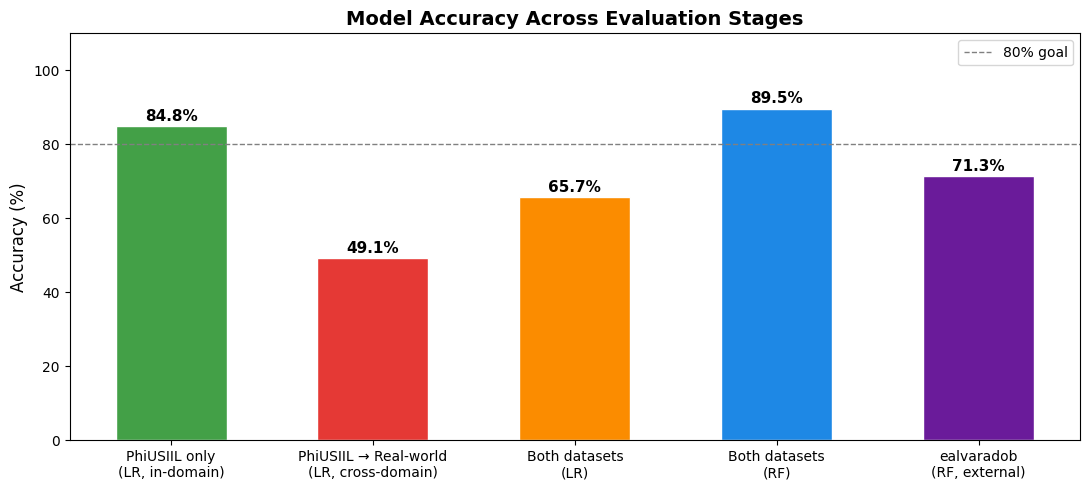

In [16]:
# Chart 1: Accuracy across all evaluation stages
stages = [
    "PhiUSIIL only\n(LR, in-domain)",
    "PhiUSIIL → Real-world\n(LR, cross-domain)",
    "Both datasets\n(LR)",
    "Both datasets\n(RF)",
    "ealvaradob\n(RF, external)",
]
accuracies = [
    acc_phi_only * 100,
    acc_cross * 100,
    acc_lr_both * 100,
    acc_rf_both * 100,
    acc_external * 100,
]
colors = ["#43A047", "#E53935", "#FB8C00", "#1E88E5", "#6A1B9A"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(stages, accuracies, color=colors, width=0.55, edgecolor="white")
ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Model Accuracy Across Evaluation Stages", fontsize=14, fontweight="bold")
ax.axhline(y=80, color="gray", linestyle="--", linewidth=1, label="80% goal")

for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

ax.legend()
plt.tight_layout()
plt.savefig("accuracy_stages.png", dpi=150, bbox_inches="tight")
plt.show()


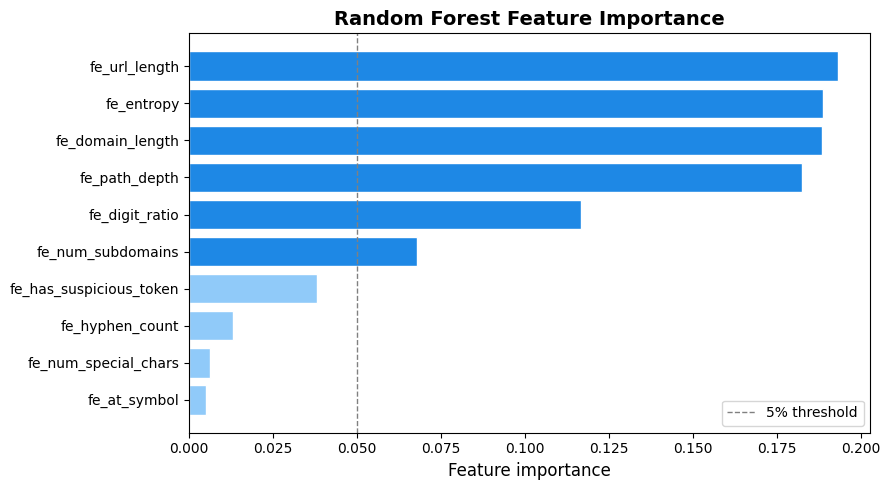

In [17]:
# Chart 2: Feature importance
top10 = importances.head(10)
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#1E88E5" if v >= 0.05 else "#90CAF9" for v in top10.values]
ax.barh(top10.index[::-1], top10.values[::-1], color=bar_colors[::-1], edgecolor="white")
ax.set_xlabel("Feature importance", fontsize=12)
ax.set_title("Random Forest Feature Importance", fontsize=14, fontweight="bold")
ax.axvline(x=0.05, color="gray", linestyle="--", linewidth=1, label="5% threshold")
ax.legend()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


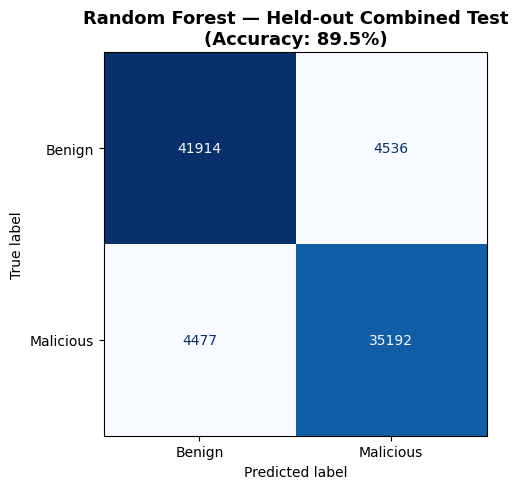

In [18]:
# Chart 3: Confusion matrix on held-out combined test set
cm = confusion_matrix(ya_te, rf_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malicious"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(
    f"Random Forest — Held-out Combined Test\n(Accuracy: {acc_rf_both*100:.1f}%)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()
